# IOAI field

## Setup

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from core import (
    FieldConfig, EvalConfig, evaluate_model,
    render_heatmap, render_masks,
    make_batch, count_params, ConstModel
)

SEED = 2026

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# fake config for trivial solutions
eval_cfg_fake = EvalConfig(
    n_per_region=512,
    seed=SEED,
    range_mode="p99",
    entropy_runs=10,
    entropy_mode="std",
    enforce_unit_interval=True,
    entropy_min=-2026,
    entropy_max=2026,
    max_params=20260,
    param_penalty=0.5,
    ignore_torch_check=True  # this checks if model is from Torch
)

eval_cfg = EvalConfig(
    n_per_region=512,
    seed=SEED,
    range_mode="p99",
    entropy_runs=10,
    entropy_mode="std",
    enforce_unit_interval=True,
    entropy_min=-2026,
    entropy_max=2026,
    max_params=20260,
    param_penalty=0.5,
)

---
## Visualization

Three visualisations are produced:

- **Heatmap (in logarithmic scale)**
- **Region masks** — one image per each letter
- **Heatmap** without the first I letter

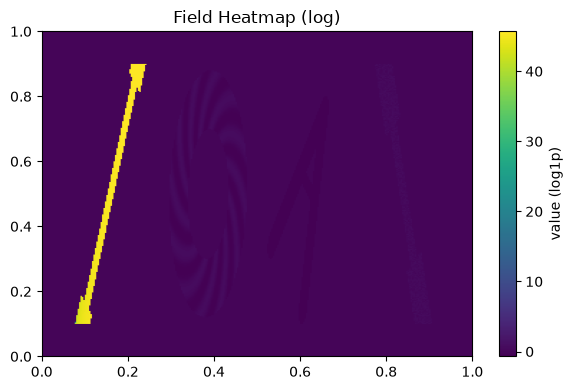

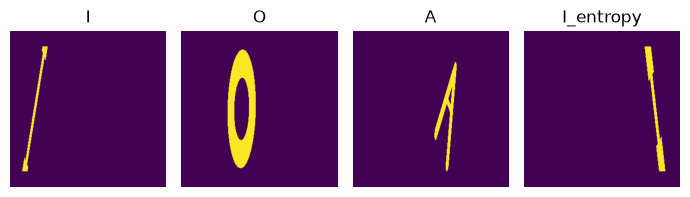

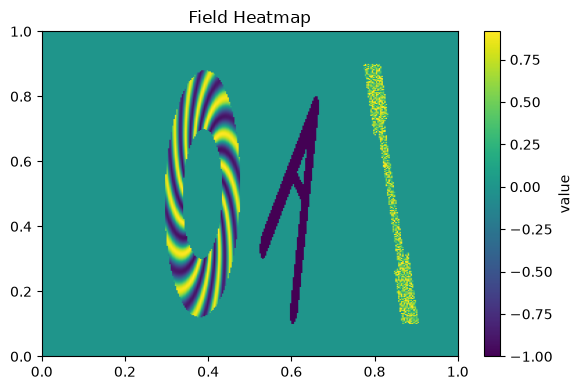

In [2]:
# The grader OVERLAYS the hidden leaderboard config onto data/train_config/ and
# retrains this notebook on it. So load the config from disk (do NOT hardcode it) --
# that is what makes your training code generalise to the hidden evaluation field.

TRAIN_DIR = Path("data/train_config")
with open(TRAIN_DIR / "field_config.json") as f:
    cfg = FieldConfig(**json.load(f))

_ = render_heatmap(cfg, resolution=300, log_scale=True)
_ = render_masks(cfg, resolution=300)
_ = render_heatmap(cfg, resolution=300, log_scale=False, exclude=("I",))

---
## Trivial solutions (not working for submission)

Before training a network it is useful to know what *trivial* strategies can achieve.


### Trivial 1 — Predict zero everywhere

Background region is perfectly predicted, `I` and `O` have some scores due to the scale normalisation.

In [3]:
scores = evaluate_model(ConstModel(0), cfg, eval_cfg_fake)
print(scores["__explain__"])

[I]
  I: n=512, mae=4.92312e+19, scale=9.36781e+19.
  score = 1 - min(mae/scale, 1) = 1 - min(4.92312e+19/9.36781e+19, 1) = 0.474464.

[O]
  O: n=512, mae=0.574407, scale=1.82463.
  score = 1 - min(mae/scale, 1) = 1 - min(0.574407/1.82463, 1) = 0.685193.

[A]
  A: n=512, mae=1, scale=0.
  constant target => using scale=1.0.
  score = 1 - min(mae/1.0, 1) = 0.

[I_entropy]
  I_entropy: n=512, runs=10, mode=std.
  Rule: if any run is outside [-2026,2026], point score=0.
  Final score = mean(point scores) = 0.

[bg]
  bg: n=512, mae=0, scale=0.1.
  score = 1 - min(mae/scale, 1) = 1 - min(0/0.1, 1) = 1.

[param multiplier]
  Params: skipped (non-torch model).

[total]
  Total: weighted mean of region scores * 100 = 43.1931.


### Trivial 2 — Predict $-1$ everywhere

**A** region perfectly predicted

In [4]:
scores = evaluate_model(ConstModel(-1), cfg, eval_cfg_fake)
print(scores["__explain__"])

[I]
  I: n=512, mae=4.92312e+19, scale=9.36781e+19.
  score = 1 - min(mae/scale, 1) = 1 - min(4.92312e+19/9.36781e+19, 1) = 0.474464.

[O]
  O: n=512, mae=1.01289, scale=1.82463.
  score = 1 - min(mae/scale, 1) = 1 - min(1.01289/1.82463, 1) = 0.444876.

[A]
  A: n=512, mae=0, scale=0.
  constant target => using scale=1.0.
  score = 1 - min(mae/1.0, 1) = 1.

[I_entropy]
  I_entropy: n=512, runs=10, mode=std.
  Rule: if any run is outside [-2026,2026], point score=0.
  Final score = mean(point scores) = 0.

[bg]
  bg: n=512, mae=1, scale=0.1.
  score = 1 - min(mae/scale, 1) = 1 - min(1/0.1, 1) = 0.

[param multiplier]
  Params: skipped (non-torch model).

[total]
  Total: weighted mean of region scores * 100 = 38.3868.


---
## Baseline Solution

In [ ]:
from custom_model import CustomModel

# Reset before model construction so rerunning earlier notebook cells does not
# change initialization or dropout randomness.
seed_everything(SEED)

model = CustomModel(hidden=[32]*3, dropout=0.5)
model.train()
print('params:', count_params(model))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
batch_size = 4096

for epoch in range(1, epochs + 1):
    xy, y = make_batch(
        batch_size,
        cfg,
        exclude_regions=('I', 'I_entropy'),
        stratified=True,
        seed=SEED + epoch,
    )
    xy_t = torch.tensor(xy, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    optimizer.zero_grad()
    pred = model(xy_t)
    loss = ((pred - y_t) ** 2).mean()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        scores = evaluate_model(model, cfg, eval_cfg)
        print(f"epoch {epoch:03d} | loss={loss.item():.6g} | total={scores['total_score']:.2f}")

scores = evaluate_model(model, cfg, eval_cfg)
print(scores['__explain__'])


params: 2241


---
## Save the model — REQUIRED

The grader loads `model.pt` and scores it. Save your trained model as a whole `nn.Module` (not a `state_dict`).


In [ ]:
import torch
torch.save(model, "model.pt")
print("saved model.pt")
